In [1]:
import pandas as pd
import numpy as np

In [3]:
# 1. Load the apps dataset
apps_df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_8\apps.csv\apps.csv')

# Drop the weird 'Unnamed: 0' index column if it downloaded with one
if 'Unnamed: 0' in apps_df.columns:
    apps_df = apps_df.drop('Unnamed: 0', axis=1)

In [4]:
# 2. Clean the 'Price' column (remove '$' and convert to float)
apps_df['Price'] = apps_df['Price'].astype(str).str.replace('$', '', regex=False)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

In [5]:
# 3. Clean the 'Installs' column (remove ',' and '+' and convert to numeric)
apps_df['Installs'] = apps_df['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

In [6]:
# 4. Clean the 'Size' column (convert 'M' to millions, 'k' to thousands, handle text)
def clean_size(size_str):
    size_str = str(size_str).replace(',', '')
    if size_str == 'Varies with device' or size_str == 'nan':
        return np.nan
    elif 'M' in size_str:
        return float(size_str.replace('M', '')) * 1_000_000
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) * 1_000
    else:
        return pd.to_numeric(size_str, errors='coerce')

apps_df['Size'] = apps_df['Size'].apply(clean_size)

In [7]:
# 5. Check our results!
print("--- Cleaned Data Types ---")
print(apps_df.dtypes)

# Peek at the cleaned columns
display(apps_df[['App', 'Price', 'Installs', 'Size']].head())

--- Cleaned Data Types ---
App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


,App,Price,Installs,Size
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0,10000,19.0
1,Coloring book moana,0.0,500000,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0,5000000,8.7
3,Sketch - Draw & Paint,0.0,50000000,25.0
4,Pixel Draw - Number Art Coloring Book,0.0,100000,2.8


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# 1. Count the number of apps in each category
category_counts = apps_df['Category'].value_counts()
print("--- Top 10 App Categories ---")
print(category_counts.head(10))

--- Top 10 App Categories ---
Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


C:\Users\ajasl\AppData\Local\Temp\ipykernel_14032\2966641205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="viridis", edgecolor="black")


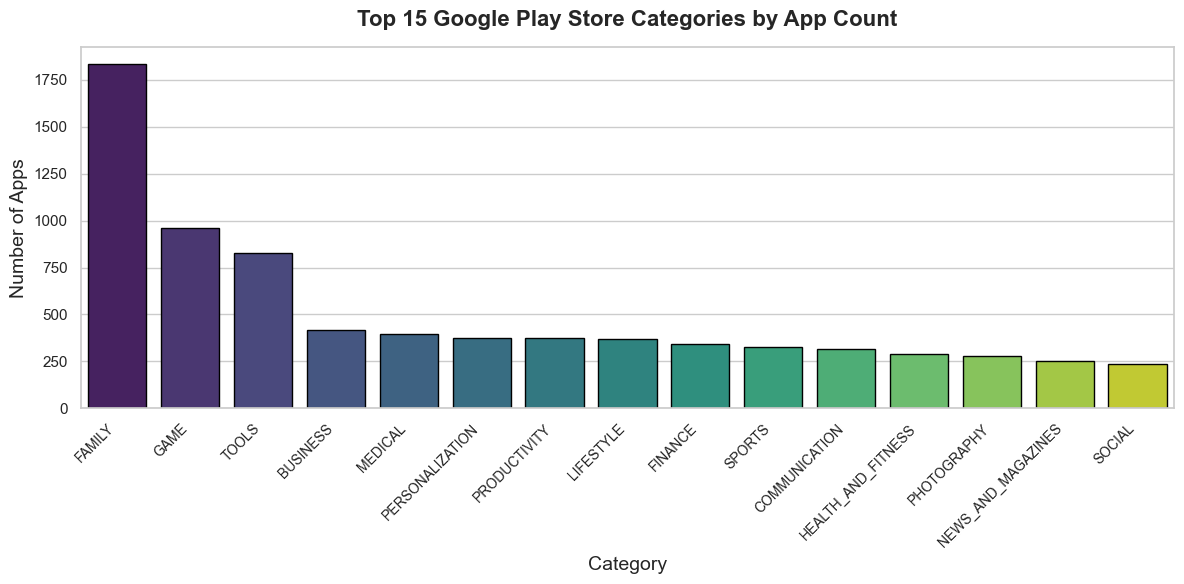

In [12]:
# 2. Visualize the app distribution across categories
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# We will plot just the top 15 categories so the chart doesn't get too crowded
ax = sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="viridis", edgecolor="black")

# 3. Add formatting and labels
plt.title('Top 15 Google Play Store Categories by App Count', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Number of Apps', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels so they don't overlap

plt.tight_layout()
plt.show()

C:\Users\ajasl\AppData\Local\Temp\ipykernel_14032\854608686.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Type', y='Rating', data=apps_df, palette='Set2')


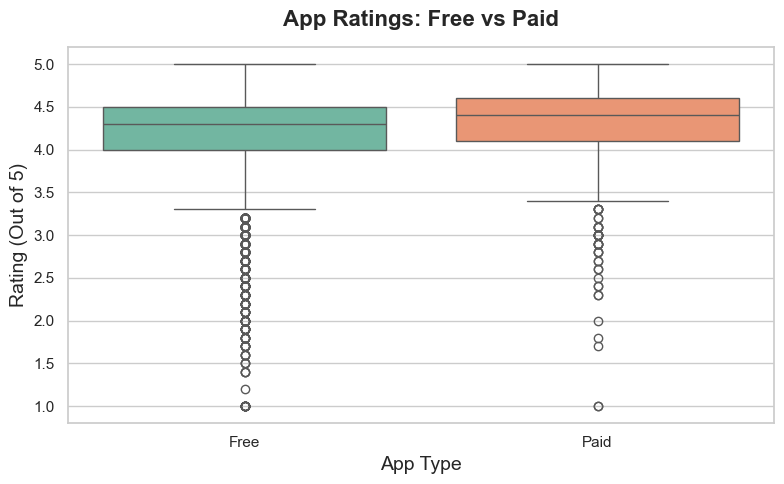

--- Average Ratings ---
Type
Free    4.166372
Paid    4.259603
Name: Rating, dtype: float64


In [17]:
# 1. Visualize the distribution of ratings for Free vs Paid apps
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Create a boxplot
ax = sns.boxplot(x='Type', y='Rating', data=apps_df, palette='Set2')

# Add formatting
plt.title('App Ratings: Free vs Paid', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('App Type', fontsize=14)
plt.ylabel('Rating (Out of 5)', fontsize=14)

plt.tight_layout()
plt.show()

# 2. Calculate the exact numerical averages
print("--- Average Ratings ---")
print(apps_df.groupby('Type')['Rating'].mean())

In [19]:
# 1. Load the user reviews dataset
reviews_df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_8\user_reviews.csv\user_reviews.csv')

In [20]:
# 2. Merge the apps and reviews datasets together based on the 'App' name
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')

In [21]:
# 3. Drop rows where the text review or sentiment is missing
merged_df = merged_df.dropna(subset=['Sentiment', 'Translated_Review'])

In [22]:
# 4. Count the different sentiments
sentiment_counts = merged_df['Sentiment'].value_counts()
print("--- User Sentiment Counts ---")
print(sentiment_counts)

--- User Sentiment Counts ---
Sentiment
Positive    23073
Negative     8005
Neutral      4851
Name: count, dtype: int64


C:\Users\ajasl\AppData\Local\Temp\ipykernel_14032\2365478906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=["#2ecc71", "#e74c3c", "#95a5a6"], edgecolor="black")


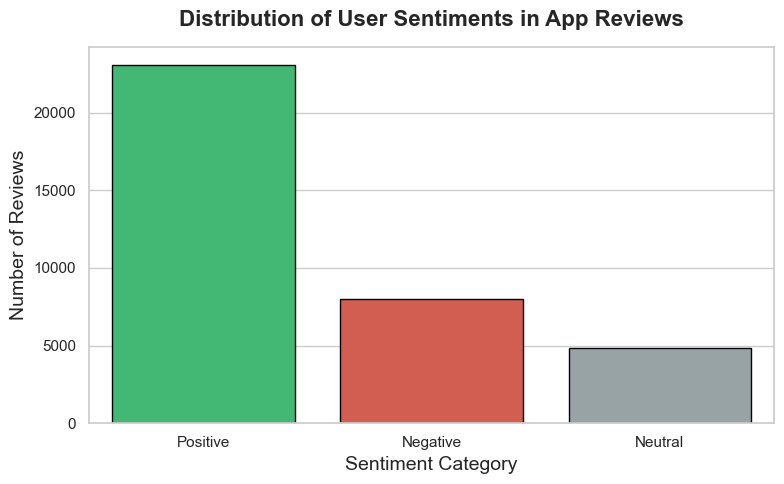

In [23]:
# 5. Visualize the overall Sentiments
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Create a bar plot with custom colors (Green for positive, Red for negative, Grey for neutral)
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=["#2ecc71", "#e74c3c", "#95a5a6"], edgecolor="black")

# Add formatting
plt.title('Distribution of User Sentiments in App Reviews', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)

plt.tight_layout()
plt.show()

In [24]:
# 1. Import Plotly for interactive charts
import plotly.express as px
import pandas as pd

In [25]:
# 2. Make sure Reviews is a number
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

In [26]:
# 3. Filter the data to only show highly reviewed apps (over 1 million reviews) so the chart isn't too cluttered
top_apps = apps_df[apps_df['Reviews'] > 1000000].dropna(subset=['Rating', 'Installs'])

In [27]:
# 4. Create the Interactive Scatter Plot!
fig = px.scatter(
    top_apps,
    x='Reviews',
    y='Rating',
    size='Installs',       # Bubble size is based on number of installs
    color='Category',      # Different colors for different categories
    hover_name='App',      # Shows the app name when you hover your mouse!
    title='Interactive View: Top Apps by Reviews and Ratings (Hover over the bubbles!)',
    log_x=True,            # Uses a logarithmic scale so the dots don't all bunch up
    template='plotly_white',
    height=600
)

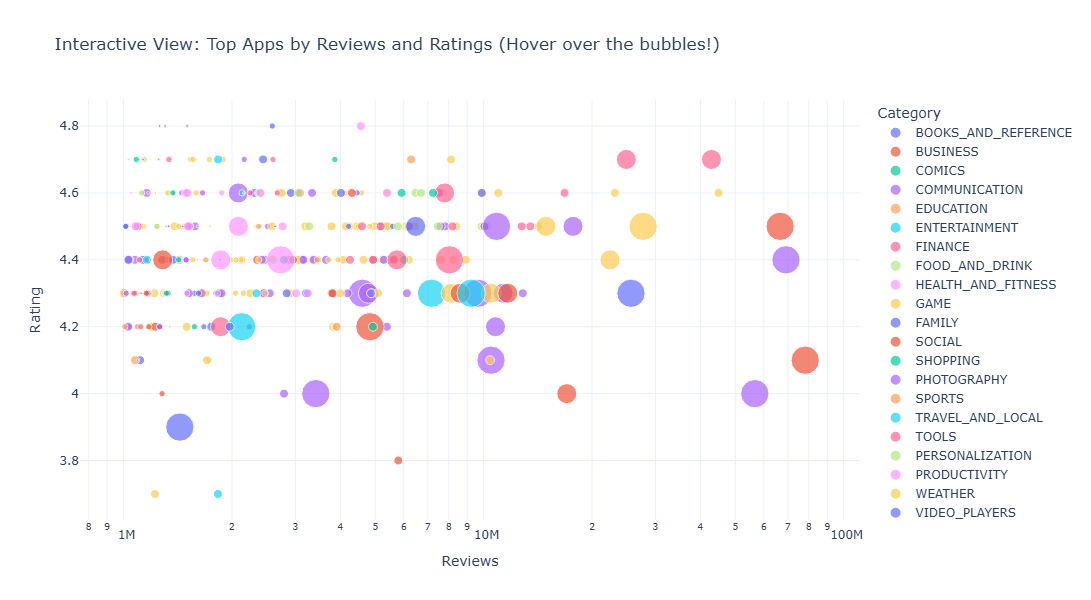

In [28]:
# 5. Show the interactive plot
fig.show()